# Prueba D - Telefonía RM y contraste regional mínimo

## Objetivo

Se construye una prueba end-to-end sobre trazas de telefonía móvil para demostrar el bloque de traces con una fuente más masiva y menos semántica que Foursquare. El objetivo es mostrar que el módulo puede:

1. importar una fuente de puntos con cobertura espacio-temporal amplia,
2. validar su estructura mínima como trazas,
3. inferir viajes con **`consecutive_clusters`**
4. derivar flows comparables y persistibles,
5. y contrastar un baseline metropolitano con una punta AM y una ruta regional mínima en Ñuble.

En esta prueba el análisis es **no ponderado**. Por ello, los flows deben interpretarse como conteos observados derivados de registros discretos, no como estimaciones expandidas a población.

## Contexto y preprocess integrado

La lógica general del preprocess es la siguiente:

- cargar el parquet crudo con las columnas mínimas relevantes;
- inspeccionar rápidamente su cobertura temporal y espacial;
- construir un subconjunto para la **Región Metropolitana**;
- dentro de RM, seleccionar una **semana laboral base**;
- construir además un subconjunto de **Ñuble** como ruta regional secundaria;
- y dejar como resultado final dos dataframes listos para el flujo del módulo:
    - `df_rm_week`
    - `df_nuble`

Esta prueba privilegia la cobertura espacio-temporal por sobre la riqueza semántica atributiva. Por ello, el valor principal de la fuente está en su volumen y en la posibilidad de producir flows comparables desde puntos discretos.

In [ ]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / "data" / "telefonia"
RAW_PARQUET_PATH = DATA_PATH / "CENIA_20231101_000000000808.parquet"

ARTIFACTS_ROOT = REPO_ROOT / "data" / "flows" / "demo_6_telefonia_traces"
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 140)

from pylondrina.importing_traces import import_traces_from_dataframe, ImportTraceOptions
from pylondrina.validation_traces import validate_traces, TraceValidationOptions
from pylondrina.transforms.inference import infer_trips_from_traces, InferTripsOptions
from pylondrina.validation import validate_trips, ValidationOptions
from pylondrina.transforms.cleaning import clean_trips, CleanOptions
from pylondrina.transforms.filtering import filter_trips, FilterOptions, TimeFilter
from pylondrina.transforms.flows import build_flows, FlowBuildOptions
from pylondrina.io.flows import write_flows, WriteFlowsOptions
from pylondrina.schema import TraceSchema, TripSchema, FieldSpec, DomainSpec

## Carga del dataset crudo

Se cargan únicamente las columnas mínimas necesarias para esta prueba. Esto mantiene el preprocess manejable y deja claro que la fuente es, ante todo, una tabla de puntos discretos con identificador de usuario, tiempo y coordenadas.

In [4]:
RAW_COLS = [
    "hashed_imsi_CENIA",
    "end_absolutetime_ts",
    "end_geo_lat",
    "end_geo_lon",
    "code_region",
    "code_commune",
]

df_raw = pd.read_parquet(RAW_PARQUET_PATH, columns=RAW_COLS).copy()
df_raw["end_absolutetime_ts"] = pd.to_datetime(df_raw["end_absolutetime_ts"], errors="coerce", utc=True)
df_raw["end_geo_lat"] = pd.to_numeric(df_raw["end_geo_lat"], errors="coerce")
df_raw["end_geo_lon"] = pd.to_numeric(df_raw["end_geo_lon"], errors="coerce")

display(df_raw.head())
print("Shape raw:", df_raw.shape)

,hashed_imsi_CENIA,end_absolutetime_ts,end_geo_lat,end_geo_lon,code_region,code_commune
0,0bef2171958a4597b111481cb6ae2c09eeb08859a2a6ee26a5f259cc4ca2c51b,2023-11-29 07:45:23+00:00,-20.9618,-69.6600,1,1401
1,a6fd9f940f6d9dc77b90d4ba1a7286d3785414d2943ce31ebb22415aeed8d939,2023-11-19 09:31:59+00:00,-20.2794,-70.0947,1,1107
2,905fa3cd1654a96c9d4fe92078e88fb71ac4b544483c162eddcaa61fee6c2482,2023-11-20 10:15:37+00:00,-20.2633,-70.0999,1,1107
3,a6fd9f940f6d9dc77b90d4ba1a7286d3785414d2943ce31ebb22415aeed8d939,2023-11-03 07:45:27+00:00,-20.2507,-69.7853,1,1401
4,400ed9278b23e35d4cedfdbe5df99cf20d60d995cf427dc8091205e46e5dd0c1,2023-11-29 13:46:41+00:00,-20.7420,-69.6570,1,1401


Shape raw: (1783793, 6)


## Vista rápida del dataset crudo

Antes de construir subconjuntos regionales, conviene dejar visible una caracterización mínima del input crudo: número de filas, usuarios, regiones, comunas y cobertura temporal observada.

In [5]:
raw_summary = pd.Series(
    {
        "n_rows": len(df_raw),
        "n_users": df_raw["hashed_imsi_CENIA"].nunique(dropna=True),
        "n_regions": df_raw["code_region"].nunique(dropna=True),
        "n_communes": df_raw["code_commune"].nunique(dropna=True),
        "min_ts_raw": df_raw["end_absolutetime_ts"].min(),
        "max_ts_raw": df_raw["end_absolutetime_ts"].max(),
    },
    name="value",
)

display(raw_summary.to_frame())

top_regions = (
    df_raw["code_region"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("code_region")
    .reset_index(name="n_points")
)
display(top_regions.head(20))

top_communes = (
    df_raw["code_commune"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("code_commune")
    .reset_index(name="n_points")
)
display(top_communes.head(15))

,value
n_rows,1783793
n_users,1372042
n_regions,16
n_communes,345
min_ts_raw,2023-11-01 00:00:34+00:00
max_ts_raw,2023-11-30 23:15:00+00:00


,code_region,n_points
0,13,714134
1,5,136200
2,7,127553
3,6,124325
4,8,106656
5,10,92681
6,2,88327
7,9,85556
8,4,79056
9,14,57002


,code_commune,n_points
0,13114,64553
1,13101,59780
2,13123,51692
3,13119,51455
4,2101,43001
5,13201,41760
6,6101,39363
7,13110,33848
8,13124,31998
9,13125,24096


## Subconjunto metropolitano y semana base

Tal como se dejó en el notebook de preprocess, se construye primero el subconjunto de la Región Metropolitana y luego se selecciona una semana base. Esta semana funciona como universo principal de la prueba.

In [6]:
# Región Metropolitana
df_rm = df_raw[df_raw["code_region"] == 13].copy()

# Semana base RM
week_start = pd.Timestamp("2023-11-20 00:00:00", tz="UTC")
week_end = week_start + pd.Timedelta(days=7)

df_rm_week = df_rm[
    (df_rm["end_absolutetime_ts"] >= week_start) &
    (df_rm["end_absolutetime_ts"] < week_end)
].copy()

df_rm_week = df_rm_week.drop_duplicates(
    subset=["hashed_imsi_CENIA", "end_absolutetime_ts", "end_geo_lat", "end_geo_lon", "code_region", "code_commune"],
    keep="first",
).reset_index(drop=True)

df_rm_week["point_id_src"] = [f"rm_p{i}" for i in range(len(df_rm_week))]

display(df_rm_week.head())
print("Shape RM week:", df_rm_week.shape)

,hashed_imsi_CENIA,end_absolutetime_ts,end_geo_lat,end_geo_lon,code_region,code_commune,point_id_src
0,d9b6e709e10e4a9ca93921e6bd7008839c38b7239d9fd8d17358f4b773f9f77f,2023-11-21 09:24:55+00:00,-33.6632,-70.8054,13,13403,rm_p0
1,caf3b47bf61b2e9b0e01af18c16a428d46345af4841cb1778bdf12513f5d0cb3,2023-11-21 09:00:08+00:00,-33.4663,-70.9857,13,13503,rm_p1
2,0887c474fc6554132cd7d0e18ead029a1361b9bf81a1dfb4225efdd5771522b5,2023-11-21 17:30:10+00:00,-33.4450,-70.5513,13,13113,rm_p2
3,7c10f1ef407563b794ec97a093b03c9c635453823987a5efc04238ecb394e7d1,2023-11-20 11:02:56+00:00,-33.4228,-70.6572,13,13108,rm_p3
4,c318c4088c20667161cba913cba236051d80cbfa78e3a923fd73612fe19e7ee3,2023-11-21 16:45:18+00:00,-33.5492,-70.6306,13,13111,rm_p4


Shape RM week: (184458, 7)


## Subconjunto regional secundario: Ñuble

Como contraste regional mínimo, se conserva también un subconjunto de Ñuble. Aquí no se fuerza una semana específica, porque el volumen es bastante menor y el objetivo es solo demostrar una ruta mínima adicional desde traces hasta flows.

In [7]:
df_nuble = df_raw[df_raw["code_region"] == 16].copy()

df_nuble = df_nuble.drop_duplicates(
    subset=["hashed_imsi_CENIA", "end_absolutetime_ts", "end_geo_lat", "end_geo_lon", "code_region", "code_commune"],
    keep="first",
).reset_index(drop=True)

df_nuble["point_id_src"] = [f"nb_p{i}" for i in range(len(df_nuble))]

display(df_nuble.head())
print("Shape Ñuble:", df_nuble.shape)

,hashed_imsi_CENIA,end_absolutetime_ts,end_geo_lat,end_geo_lon,code_region,code_commune,point_id_src
0,c2916b051ff8b94a49456daeab9cd3797c293e3f158ca9b89190e89768d01e71,2023-11-30 18:36:18+00:00,-36.6764,-71.8422,16,16302,nb_p0
1,a6fd9f940f6d9dc77b90d4ba1a7286d3785414d2943ce31ebb22415aeed8d939,2023-11-11 11:00:10+00:00,-36.7666,-71.9906,16,16108,nb_p1
2,89996b116eb132e54eb57e9a8ac5dd60b60e76b6465e7910914c5916f7810d0d,2023-11-23 08:32:15+00:00,-36.7493,-72.3002,16,16102,nb_p2
3,b607e19a7658cfe826b635d5c22958796bb1b2cb529ebcddfdbd86da97cd43e2,2023-11-07 12:30:25+00:00,-36.4983,-72.2215,16,16305,nb_p3
4,92f48db1642c72cbe30545e9af49252814652a68683e8a4dc8f616266341eb3e,2023-11-09 10:47:05+00:00,-36.7493,-72.3002,16,16102,nb_p4


Shape Ñuble: (52292, 7)


## Exploración mínima de los subconjuntos finales

Antes de entrar al módulo, conviene verificar la cobertura temporal y el volumen de ambos dataframes finales de entrada.

In [8]:
rm_summary = pd.Series(
    {
        "rows": len(df_rm_week),
        "users": df_rm_week["hashed_imsi_CENIA"].nunique(dropna=True),
        "min_ts": df_rm_week["end_absolutetime_ts"].min(),
        "max_ts": df_rm_week["end_absolutetime_ts"].max(),
        "n_communes": df_rm_week["code_commune"].nunique(dropna=True),
    },
    name="RM_week",
)

nuble_summary = pd.Series(
    {
        "rows": len(df_nuble),
        "users": df_nuble["hashed_imsi_CENIA"].nunique(dropna=True),
        "min_ts": df_nuble["end_absolutetime_ts"].min(),
        "max_ts": df_nuble["end_absolutetime_ts"].max(),
        "n_communes": df_nuble["code_commune"].nunique(dropna=True),
    },
    name="Nuble",
)

display(pd.concat([rm_summary, nuble_summary], axis=1))

,RM_week,Nuble
rows,184458,52292
users,151305,41101
min_ts,2023-11-20 00:00:14+00:00,2023-11-01 07:00:12+00:00
max_ts,2023-11-26 23:59:19+00:00,2023-11-30 23:03:38+00:00
n_communes,52,21


Se obtienen así dos fuentes operables para el resto de la prueba:

- `df_rm_week` como baseline principal de la RM,
- `df_nuble` como ruta regional secundaria.

A partir de este punto, el notebook entra al bloque de trazas del módulo: importación, validación, inferencia de viajes y derivación de flows.

In [9]:
def _issues_to_frame(report):
    issues = getattr(report, "issues", None) or []
    if not issues:
        return pd.DataFrame(columns=["level", "code", "field", "row_count", "message"])
    rows = []
    for issue in issues:
        rows.append(
            {
                "level": getattr(issue, "level", None),
                "code": getattr(issue, "code", None),
                "field": getattr(issue, "field", None),
                "row_count": getattr(issue, "row_count", None),
                "message": getattr(issue, "message", None),
            }
        )
    return pd.DataFrame(rows)


def show_report_digest(report, title: str, top_n_issues: int = 10):
    print(f"\n===== {title} =====")
    print("ok:", getattr(report, "ok", None))
    summary = getattr(report, "summary", None)
    if summary is not None:
        print("summary:")
        display(pd.DataFrame([summary]))
    parameters = getattr(report, "parameters", None)
    if parameters is not None:
        print("parameters:")
        display(pd.DataFrame([parameters]))
    issues_df = _issues_to_frame(report)
    print("n_issues:", len(issues_df))
    if not issues_df.empty:
        print("issue_counts_by_level:")
        display(
            issues_df["level"]
            .astype(str)
            .value_counts(dropna=False)
            .rename_axis("level")
            .reset_index(name="count")
        )
        print("top_issues:")
        display(issues_df.head(top_n_issues))


def compute_flow_validation_bundle(flow_dataset, *, top_k: int = 20, coverage_top_n: int = 100):
    flows_df = flow_dataset.flows.copy()

    if len(flows_df) == 0:
        summary = pd.DataFrame(
            [{"flow_rows": 0, "total_flow_value": 0.0, f"top_{coverage_top_n}_coverage_ratio": 0.0, "intrazona_ratio": 0.0}]
        )
        empty = pd.DataFrame()
        return summary, empty, empty, empty

    flows_df["flow_value"] = pd.to_numeric(flows_df["flow_value"], errors="coerce").fillna(0.0)
    flows_df["flow_count"] = pd.to_numeric(flows_df["flow_count"], errors="coerce").fillna(0)

    total_mass = float(flows_df["flow_value"].sum())
    n_flows = int(len(flows_df))
    n_top = min(coverage_top_n, n_flows)

    flows_sorted = flows_df.sort_values("flow_value", ascending=False).copy()
    top_flows = flows_sorted.head(top_k).copy()

    top_mass = float(flows_sorted.head(n_top)["flow_value"].sum())
    coverage_ratio = (top_mass / total_mass) if total_mass > 0 else 0.0

    top_origins = (
        flows_df.groupby("origin_h3_index", dropna=False)["flow_value"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="flow_value")
    )

    top_destinations = (
        flows_df.groupby("destination_h3_index", dropna=False)["flow_value"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="flow_value")
    )

    intrazona_mass = float(
        flows_df.loc[
            flows_df["origin_h3_index"] == flows_df["destination_h3_index"], "flow_value"
        ].sum()
    )
    intrazona_ratio = (intrazona_mass / total_mass) if total_mass > 0 else 0.0

    summary = pd.DataFrame(
        [
            {
                "flow_rows": n_flows,
                "total_flow_value": total_mass,
                f"top_{n_top}_coverage_ratio": coverage_ratio,
                "intrazona_ratio": intrazona_ratio,
            }
        ]
    )

    cols_top = [c for c in ["flow_id", "origin_h3_index", "destination_h3_index", "flow_count", "flow_value"] if c in top_flows.columns]
    top_flows = top_flows[cols_top].reset_index(drop=True)

    return summary, top_flows, top_origins, top_destinations

## Preparación del import de trazas

Se define un esquema mínimo de trazas para telefonía. Dado que esta fuente tiene muy poca semántica atributiva, el foco del schema queda puesto en el núcleo estructural: identificador de punto, usuario, tiempo y coordenadas.

In [10]:
TELEFONIA_TRACE_SCHEMA = TraceSchema(
    version="telefonia-traces-d1",
    fields={
        "point_id": FieldSpec(
            "point_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "unique": True,
                "length": {"min": 1, "max": 120},
            },
        ),
        "user_id": FieldSpec(
            "user_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "time_utc": FieldSpec(
            "time_utc",
            "datetime",
            required=True,
            constraints={
                "nullable": False,
                "datetime": {"allow_naive": False},
            },
        ),
        "latitude": FieldSpec(
            "latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "longitude": FieldSpec(
            "longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
    },
    required=["point_id", "user_id", "time_utc", "latitude", "longitude"],
    timezone="UTC",
)

TELEFONIA_TRACE_FIELD_CORR = {
    "user_id": "hashed_imsi_CENIA",
    "time_utc": "end_absolutetime_ts",
    "latitude": "end_geo_lat",
    "longitude": "end_geo_lon",
}

TELEFONIA_TRACE_OPTIONS = ImportTraceOptions(
    keep_extra_fields=True,
    selected_fields=None,
    strict=False,
    source_timezone=None,
)

TELEFONIA_TRACE_PROVENANCE = {
    "source": {
        "name": "Telefonia",
        "entity": "traces",
        "version": "rm_week_or_nuble_month",
    },
    "notes": [
        "puntos discretos de telefonía",
        "análisis no ponderado",
        "sin semántica atributiva rica",
    ],
}

display(
    pd.DataFrame(
        {
            "field": list(TELEFONIA_TRACE_FIELD_CORR.keys()),
            "source_field": list(TELEFONIA_TRACE_FIELD_CORR.values()),
        }
    )
)

,field,source_field
0,point_id,point_id_src
1,user_id,hashed_imsi_CENIA
2,time_utc,end_absolutetime_ts
3,latitude,end_geo_lat
4,longitude,end_geo_lon


## Importación del baseline de trazas RM

Se importa primero el subconjunto metropolitano semanal. Este será el input principal para el baseline y el contraste de punta AM.

In [11]:
telefonia_rm_traces, telefonia_rm_import_report = import_traces_from_dataframe(
    df_rm_week,
    schema=TELEFONIA_TRACE_SCHEMA,
    source_name="Telefonia",
    options=TELEFONIA_TRACE_OPTIONS,
    field_correspondence=TELEFONIA_TRACE_FIELD_CORR,
    provenance=TELEFONIA_TRACE_PROVENANCE,
)

show_report_digest(telefonia_rm_import_report, "Reporte de importación de trazas - RM")

print("\nTraceDataset RM importado")
print("shape:", telefonia_rm_traces.data.shape)
print("metadata['is_validated']:", telefonia_rm_traces.metadata.get("is_validated"))

display(telefonia_rm_traces.data.head())


===== Reporte de importación de trazas - RM =====
ok: True
summary:


,rows_in,rows_out,n_fields_mapped,point_id_generated
0,184458,184458,5,False


parameters:


,source_name,strict,keep_extra_fields,selected_fields,source_timezone,schema_version,crs,timezone,has_field_correspondence
0,Telefonia,False,True,None,None,telefonia-traces-d1,EPSG:4326,UTC,True


n_issues: 0

TraceDataset RM importado
shape: (184458, 7)
metadata['is_validated']: False


,point_id,user_id,time_utc,latitude,longitude,code_region,code_commune
0,rm_p0,d9b6e709e10e4a9ca93921e6bd7008839c38b7239d9fd8d17358f4b773f9f77f,2023-11-21 09:24:55+00:00,-33.6632,-70.8054,13,13403
1,rm_p1,caf3b47bf61b2e9b0e01af18c16a428d46345af4841cb1778bdf12513f5d0cb3,2023-11-21 09:00:08+00:00,-33.4663,-70.9857,13,13503
2,rm_p2,0887c474fc6554132cd7d0e18ead029a1361b9bf81a1dfb4225efdd5771522b5,2023-11-21 17:30:10+00:00,-33.4450,-70.5513,13,13113
3,rm_p3,7c10f1ef407563b794ec97a093b03c9c635453823987a5efc04238ecb394e7d1,2023-11-20 11:02:56+00:00,-33.4228,-70.6572,13,13108
4,rm_p4,c318c4088c20667161cba913cba236051d80cbfa78e3a923fd73612fe19e7ee3,2023-11-21 16:45:18+00:00,-33.5492,-70.6306,13,13111


## Validación de trazas RM

Se valida el dataset de trazas para asegurar required, tipos y monotonicidad temporal por usuario antes de inferir viajes.

In [12]:
telefonia_trace_validate_options = TraceValidationOptions(
    strict=False,
    sample_rows_per_issue=5,
    validate_required_fields=True,
    validate_types_and_formats=True,
    validate_constraints=True,
    validate_monotonic_time_per_user=True,
)

telefonia_rm_validate_traces_report = validate_traces(
    telefonia_rm_traces,
    options=telefonia_trace_validate_options,
)

show_report_digest(telefonia_rm_validate_traces_report, "Validación de trazas - RM")

print("\nEstado validado después de validate_traces:")
print("metadata['is_validated']:", telefonia_rm_traces.metadata.get("is_validated"))


===== Validación de trazas - RM =====
ok: None
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version
0,True,184458,1,0,1,0,"{'error': 0, 'warning': 1, 'info': 0}",{'VAL.TEMPORAL.NON_MONOTONIC_TIME': 1},"[point_id, user_id, time_utc, latitude, longitude]","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'monotonic_time_per_user': True}",telefonia-traces-d1


parameters:


""
0


n_issues: 1
issue_counts_by_level:


,level,count
0,warning,1


top_issues:


,level,code,field,row_count,message
0,warning,VAL.TEMPORAL.NON_MONOTONIC_TIME,time_utc,16473,Se detectaron secuencias temporales no monotónicas por usuario en 'time_utc'.



Estado validado después de validate_traces:
metadata['is_validated']: True


## Preparación del schema de trips inferidos

Los trips inferidos desde telefonía se construyen como viajes simples entre puntos consecutivos válidos del mismo usuario. No se agrega peso porque el análisis es no ponderado.

In [23]:
TELEFONIA_TRIPS_SCHEMA = TripSchema(
    version="telefonia-inferred-trips-d1",
    fields={
        "movement_id": FieldSpec(
            "movement_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "unique": True,
                "length": {"min": 1, "max": 120},
            },
        ),
        "trip_id": FieldSpec(
            "trip_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "movement_seq": FieldSpec(
            "movement_seq",
            "int",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": 0},
            },
        ),
        "user_id": FieldSpec(
            "user_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "origin_longitude": FieldSpec(
            "origin_longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
        "origin_latitude": FieldSpec(
            "origin_latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "destination_longitude": FieldSpec(
            "destination_longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
        "destination_latitude": FieldSpec(
            "destination_latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "origin_time_utc": FieldSpec(
            "origin_time_utc",
            "datetime",
            required=False,
            constraints={
                "nullable": True,
                "datetime": {"allow_naive": False},
            },
        ),
        "destination_time_utc": FieldSpec(
            "destination_time_utc",
            "datetime",
            required=False,
            constraints={
                "nullable": True,
                "datetime": {"allow_naive": False},
            },
        ),
        "origin_h3_index": FieldSpec(
            "origin_h3_index",
            "string",
            required=False,
            constraints={
                "nullable": True,
                "h3": {"require_valid": True, "resolution": 10},
            },
        ),
        "destination_h3_index": FieldSpec(
            "destination_h3_index",
            "string",
            required=False,
            constraints={
                "nullable": True,
                "h3": {"require_valid": True, "resolution": 10},
            },
        ),
    },
    required=[
        "movement_id",
        "trip_id",
        "movement_seq",
        "user_id",
        "origin_longitude",
        "origin_latitude",
        "destination_longitude",
        "destination_latitude",
    ],
)

TELEFONIA_INFER_OPTIONS = InferTripsOptions(
    infer_mode="consecutive_clusters",
    strict=False,
    strict_domains=False,
    require_validated_traces=True,
    drop_invalid=True,
    h3_resolution=10,
    #min_time_delta_s=180.0,
    cluster_max_time_gap_s=60.0 * 5.0,
    cluster_radius_m=250.0,
    propagate_trace_fields=None,
)

TELEFONIA_INFER_PROVENANCE = {
    "source": {
        "name": "Telefonia",
        "entity": "inferred_trips",
        "version": "consecutive_points",
    },
    "notes": [
        "inferencia desde registros discretos",
        "sin ponderación",
        "umbral temporal más estricto que Foursquare",
    ],
}

## Inferencia de viajes RM

A partir de las trazas validadas, se infieren viajes simples entre puntos consecutivos del mismo usuario. En esta fuente se usan umbrales temporales más estrictos que en Foursquare, porque el muestreo temporal y el volumen de registros permiten exigir mayor proximidad.

In [24]:
telefonia_rm_trips, telefonia_rm_infer_report = infer_trips_from_traces(
    telefonia_rm_traces,
    TELEFONIA_TRIPS_SCHEMA,
    options=TELEFONIA_INFER_OPTIONS,
    value_correspondence=None,
    provenance=TELEFONIA_INFER_PROVENANCE,
)

show_report_digest(telefonia_rm_infer_report, "Inferencia de viajes - RM")

print("\nTripDataset RM inferido")
print("shape:", telefonia_rm_trips.data.shape)
print("is_validated:", telefonia_rm_trips.metadata.get("is_validated"))

display(telefonia_rm_trips.data.head())


===== Inferencia de viajes - RM =====
ok: True
summary:


,infer_mode,n_points_in,n_candidates_in,n_candidates_dropped,n_trips_out,dropped_by_reason,n_clusters_out
0,consecutive_clusters,184458,33022,0,33022,{},184327


parameters:


,infer_mode,strict,strict_domains,require_validated_traces,drop_invalid,h3_resolution,max_time_delta_s,min_time_delta_s,min_distance_m,cluster_radius_m,cluster_max_time_gap_s,propagate_trace_fields,value_correspondence_used,validation_bypass_used
0,consecutive_clusters,False,False,True,True,10,None,None,None,250.0,300.0,{},False,False


n_issues: 3
issue_counts_by_level:


,level,count
0,info,3


top_issues:


,level,code,field,row_count,message
0,info,INF.CLUSTERS.MODE_APPLIED,None,None,Se construyeron 184327 clusters secuenciales y 33022 candidatos OD entre clusters consecutivos.
1,info,INF.H3.DERIVED,None,None,Se derivaron origin_h3_index y destination_h3_index con h3_resolution=10.
2,info,INF.OK.SUMMARY,None,None,Se infirieron 33022 viajes a partir de 184458 puntos usando infer_mode='consecutive_clusters'.



TripDataset RM inferido
shape: (33022, 12)
is_validated: False


,movement_id,user_id,origin_longitude,origin_latitude,destination_longitude,destination_latitude,origin_time_utc,destination_time_utc,trip_id,movement_seq,origin_h3_index,destination_h3_index
0,m0,0000e1f520484615804e1d256ccb01a9faa436ec689431294734592b41a52ee2,-70.7775,-33.5270,-70.7217,-33.4869,2023-11-24 21:46:14+00:00,2023-11-26 13:09:06+00:00,m0,0,8ab2c540dceffff,8ab2c555a167fff
1,m1,001b3e05aeb3599d488c9adeeb9aa3be3db8cc5dd599d7a6e5061506256ef8d1,-70.5280,-33.4779,-70.5876,-33.4517,2023-11-20 12:38:02+00:00,2023-11-23 16:31:37+00:00,m1,0,8ab2c50840e7fff,8ab2c50b63affff
2,m2,0020f79240503bd5e9dcaba7e473734c96c6ce02a70e710c00a5955c175581d2,-70.6954,-33.4788,-70.7200,-33.4240,2023-11-24 16:32:08+00:00,2023-11-24 16:45:21+00:00,m2,0,8ab2c5558aaffff,8ab2c55558b7fff
3,m3,00238be0c062d4ad84bef0e2c1f29e887be517c4b0413f53379b3023889486b5,-70.6211,-33.5292,-70.7444,-33.3329,2023-11-26 15:38:20+00:00,2023-11-26 20:31:36+00:00,m3,0,8ab2c546c987fff,8ab2c552cacffff
4,m4,00271c49303c42811391f6c41b627527b1a002d6e6b132a5eca537df39737a61,-70.6572,-33.4490,-70.6557,-33.4399,2023-11-20 12:37:09+00:00,2023-11-21 08:41:35+00:00,m4,0,8ab2c554165ffff,8ab2c554101ffff


Se observa así el paso central de esta prueba: una fuente masiva y con poca semántica atributiva ya puede traducirse a viajes OD simples dentro del mismo contrato que usan otras pruebas del proyecto.

## Validación inicial de trips RM

Antes de construir flows, se valida el dataset de trips inferidos para revisar estructura, tiempos y constraints relevantes.

In [25]:
telefonia_validate_trips_options = ValidationOptions(
    strict=False,
    max_issues=300,
    sample_rows_per_issue=5,
    validate_required_fields=True,
    validate_types_and_formats=True,
    validate_constraints=True,
    validate_domains="sample",
    domains_sample_frac=0.02,
    domains_min_in_domain_ratio=0.95,
    validate_temporal_consistency=True,
    validate_duplicates=True,
    duplicates_subset=("movement_id",),
)

telefonia_rm_validation_report_initial = validate_trips(
    telefonia_rm_trips,
    options=telefonia_validate_trips_options,
)

show_report_digest(telefonia_rm_validation_report_initial, "Validación inicial de trips - RM")

print("\nEstado validado después de validate_trips:")
print("is_validated:", telefonia_rm_trips.is_validated)
print("metadata['is_validated']:", telefonia_rm_trips.metadata.get("is_validated"))


===== Validación inicial de trips - RM =====
ok: True
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version,domains,duplicates,temporal,limits
0,True,33022,0,0,0,0,"{'error': 0, 'warning': 0, 'info': 0}",{},"[destination_h3_index, destination_latitude, destination_longitude, destination_time_utc, movement_id, movement_seq, origin_h3_index, or...","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'domains': True, 'temporal_consistency': True, 'duplicates': T...",telefonia-inferred-trips-d1,"{'mode': 'sample', 'min_required_ratio': 0.95, 'fields': {}}","{'evaluated': True, 'duplicates_subset': ['movement_id'], 'n_duplicate_rows': 0}","{'evaluated': True, 'tier': 'tier_1', 'n_checked': 33022, 'n_violations': 0, 'origin_field': 'origin_time_utc', 'destination_field': 'de...","{'max_issues': 300, 'issues_truncated': False, 'n_issues_emitted': 0, 'n_issues_detected_total': 0}"


n_issues: 0

Estado validado después de validate_trips:
is_validated: True
metadata['is_validated']: True


## Baseline RM full-day week

El baseline principal se construye queda directo de el TripDataset que se validó correctamente.

## Contraste temporal de punta AM

Para construir la punta AM semanal se deriva primero la hora local de inicio del viaje. Esto permite filtrar por hora del día sin fijar una fecha única, manteniendo el contraste sobre toda la semana base.

In [26]:
telefonia_rm_trips.data["origin_time_local"] = (
    telefonia_rm_trips.data["origin_time_utc"]
    .dt.tz_convert("America/Santiago")
)

telefonia_rm_trips.data["local_hour"] = (
    telefonia_rm_trips.data["origin_time_local"].dt.hour.astype("Int64")
)

display(
    telefonia_rm_trips.data["local_hour"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("local_hour")
    .reset_index(name="count")
)

,local_hour,count
0,0,137
1,1,115
2,2,129
3,3,25
4,4,1151
5,5,1169
6,6,1239
7,7,1281
8,8,1479
9,9,1496


In [28]:
telefonia_rm_peak_filter_options = FilterOptions(
    where={"local_hour": {"gte": 6, "lt": 10}},
    keep_metadata=True,
    strict=False,
)

telefonia_rm_trips_peak, telefonia_rm_filter_report_peak = filter_trips(
    telefonia_rm_trips,
    options=telefonia_rm_peak_filter_options,
)

show_report_digest(telefonia_rm_filter_report_peak, "Filtro contraste - RM punta AM")

display(
    pd.DataFrame(
        [
            {
                "subset": "rm_peak_am",
                "rows": len(telefonia_rm_trips_peak.data),
                "is_validated": telefonia_rm_trips_peak.is_validated,
            }
        ]
    )
)


===== Filtro contraste - RM punta AM =====
ok: True
summary:


,rows_in,rows_out,dropped_total,dropped_by_filter,filters_requested,filters_applied,filters_omitted
0,33022,5495,27527,"{'where': 27527, 'time': 0, 'bbox': 0, 'polygon': 0, 'h3_cells': 0}",[where],[where],[]


parameters:


,where,time,bbox,polygon,h3_cells,spatial_predicate,origin_h3_field,destination_h3_field,keep_metadata,strict,max_issues,sample_rows_per_issue
0,"{'local_hour': {'gte': 6, 'lt': 10}}",None,None,None,None,origin,origin_h3_index,destination_h3_index,True,False,1000,20


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,FLT.INFO.WHERE_APPLIED,None,None,Se aplicó la cláusula where y el subconjunto pasó de 33022 a 5495 filas en este eje.


,subset,rows,is_validated
0,rm_peak_am,5495,True


Se dejan así definidos los dos artefactos principales de la RM:

- un baseline de semana completa,
- y un contraste temporal de punta AM.

A continuación se construyen los flows correspondientes.

## Construcción de flows RM

Se construyen dos flows no ponderados para la RM:

1. baseline full-day week,
2. contraste punta AM.

In [45]:
if not telefonia_rm_trips.is_validated:
    raise RuntimeError("El baseline RM no quedó validado; no conviene construir flows con require_validated=True.")

if not telefonia_rm_trips_peak.is_validated:
    raise RuntimeError("El contraste RM punta AM no quedó validado; no conviene construir flows con require_validated=True.")

telefonia_flow_build_options_rm_base = FlowBuildOptions(
    h3_resolution=7,
    group_by=None,
    time_aggregation="none",
    keep_flow_to_trips=False,
    require_validated=True,
    min_trips_per_flow=6,
)

telefonia_flow_build_options_rm_peak = FlowBuildOptions(
    h3_resolution=7,
    group_by=None,
    time_aggregation="none",
    keep_flow_to_trips=False,
    require_validated=True,
    min_trips_per_flow=2,
)

telefonia_rm_flows_baseline, telefonia_rm_build_report_baseline = build_flows(
    telefonia_rm_trips,
    options=telefonia_flow_build_options_rm_base,
)

telefonia_rm_flows_peak, telefonia_rm_build_report_peak = build_flows(
    telefonia_rm_trips_peak,
    options=telefonia_flow_build_options_rm_peak,
)

show_report_digest(telefonia_rm_build_report_baseline, "Build flows - RM baseline")
show_report_digest(telefonia_rm_build_report_peak, "Build flows - RM punta AM")

print("\nColumnas FlowDataset baseline RM:")
print(telefonia_rm_flows_baseline.flows.columns.tolist())

display(telefonia_rm_flows_baseline.flows.head())


===== Build flows - RM baseline =====
ok: True
summary:


,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,33022,33022,0,606,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,7,None,none,origin,6,False,True,False,1000


n_issues: 0

===== Build flows - RM punta AM =====
ok: True
summary:


,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,5495,5495,0,585,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,7,None,none,origin,2,False,True,False,1000


n_issues: 0

Columnas FlowDataset baseline RM:
['flow_id', 'origin_h3_index', 'destination_h3_index', 'flow_count', 'flow_value']


,flow_id,origin_h3_index,destination_h3_index,flow_count,flow_value
0,flow_0000000,87b2c0853ffffff,87b2c554cffffff,7,7.0
1,flow_0000001,87b2c08edffffff,87b2c5541ffffff,7,7.0
2,flow_0000002,87b2c08edffffff,87b2c5568ffffff,10,10.0
3,flow_0000003,87b2c08edffffff,87b2c5569ffffff,6,6.0
4,flow_0000004,87b2c08edffffff,87b2c556bffffff,7,7.0


## Persistencia formal de flows RM

Se persisten ambos flows de la RM con `write_flows`, que es el mecanismo principal de persistencia formal usado en estas pruebas.

In [46]:
D_RM_BASELINE_PATH = ARTIFACTS_ROOT / "d_rm_baseline"
D_RM_PEAK_PATH = ARTIFACTS_ROOT / "d_rm_peak_am"

telefonia_rm_write_report_baseline = write_flows(
    telefonia_rm_flows_baseline,
    D_RM_BASELINE_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

telefonia_rm_write_report_peak = write_flows(
    telefonia_rm_flows_peak,
    D_RM_PEAK_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

show_report_digest(telefonia_rm_write_report_baseline, "Write flows - RM baseline")
show_report_digest(telefonia_rm_write_report_peak, "Write flows - RM punta AM")


===== Write flows - RM baseline =====
ok: True
summary:


,n_flows,n_flow_to_trips,files_written,dataset_id,artifact_id,path
0,606,None,"[flows.feather, flows.metadata.json]",flows_3e6810f533c9,art_8af1caed-ba3e-4473-84b4-7dc6a1a3fb79,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_rm_baseline.golondrina


parameters:


,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_rm_baseline.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 1
issue_counts_by_level:


...

,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_rm_peak_am.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,WRITE_FLOWS.LAYOUT.BUNDLE_OVERWRITTEN,None,None,El bundle destino ya existía y será sobrescrito porque mode='overwrite'.


## Validación visual del baseline RM

El flow principal de esta prueba es el baseline metropolitano de semana completa. Antes de insertar la captura, conviene revisar el paquete completo de validación visual.

In [47]:
d_rm_baseline_validation_summary, d_rm_baseline_top_flows, d_rm_baseline_top_origins, d_rm_baseline_top_destinations = compute_flow_validation_bundle(
    telefonia_rm_flows_baseline,
    top_k=20,
    coverage_top_n=100,
)

print("Resumen de validación visual - RM baseline")
display(d_rm_baseline_validation_summary)

print("Top-20 flows por flow_value - RM baseline")
display(d_rm_baseline_top_flows)

print("Top orígenes por masa - RM baseline")
display(d_rm_baseline_top_origins)

print("Top destinos por masa - RM baseline")
display(d_rm_baseline_top_destinations)

Resumen de validación visual - RM baseline


,flow_rows,total_flow_value,top_100_coverage_ratio,intrazona_ratio
0,606,5565.0,0.318778,0.03504


Top-20 flows por flow_value - RM baseline


,flow_id,origin_h3_index,destination_h3_index,flow_count,flow_value
0,flow_0000243,87b2c5541ffffff,87b2c5568ffffff,46,46.0
1,flow_0000476,87b2c5568ffffff,87b2c5568ffffff,45,45.0
2,flow_0000226,87b2c5541ffffff,87b2c5541ffffff,41,41.0
3,flow_0000231,87b2c5541ffffff,87b2c554cffffff,39,39.0
4,flow_0000454,87b2c5568ffffff,87b2c5541ffffff,38,38.0
5,flow_0000571,87b2c556dffffff,87b2c5568ffffff,34,34.0
6,flow_0000562,87b2c556dffffff,87b2c554cffffff,31,31.0
7,flow_0000328,87b2c554cffffff,87b2c5568ffffff,30,30.0
8,flow_0000461,87b2c5568ffffff,87b2c554cffffff,29,29.0
9,flow_0000319,87b2c554cffffff,87b2c554cffffff,27,27.0


Top orígenes por masa - RM baseline


,origin_h3_index,flow_value
0,87b2c5568ffffff,836.0
1,87b2c5541ffffff,695.0
2,87b2c554cffffff,462.0
3,87b2c556dffffff,351.0
4,87b2c556bffffff,186.0
5,87b2c556affffff,168.0
6,87b2c5569ffffff,161.0
7,87b2c5543ffffff,144.0
8,87b2c519affffff,139.0
9,87b2c5090ffffff,131.0


Top destinos por masa - RM baseline


,destination_h3_index,flow_value
0,87b2c5568ffffff,836.0
1,87b2c5541ffffff,721.0
2,87b2c554cffffff,539.0
3,87b2c556dffffff,320.0
4,87b2c556affffff,201.0
5,87b2c556bffffff,192.0
6,87b2c519affffff,157.0
7,87b2c5569ffffff,156.0
8,87b2c5543ffffff,147.0
9,87b2c554effffff,122.0


## Captura del flowmap - RM baseline

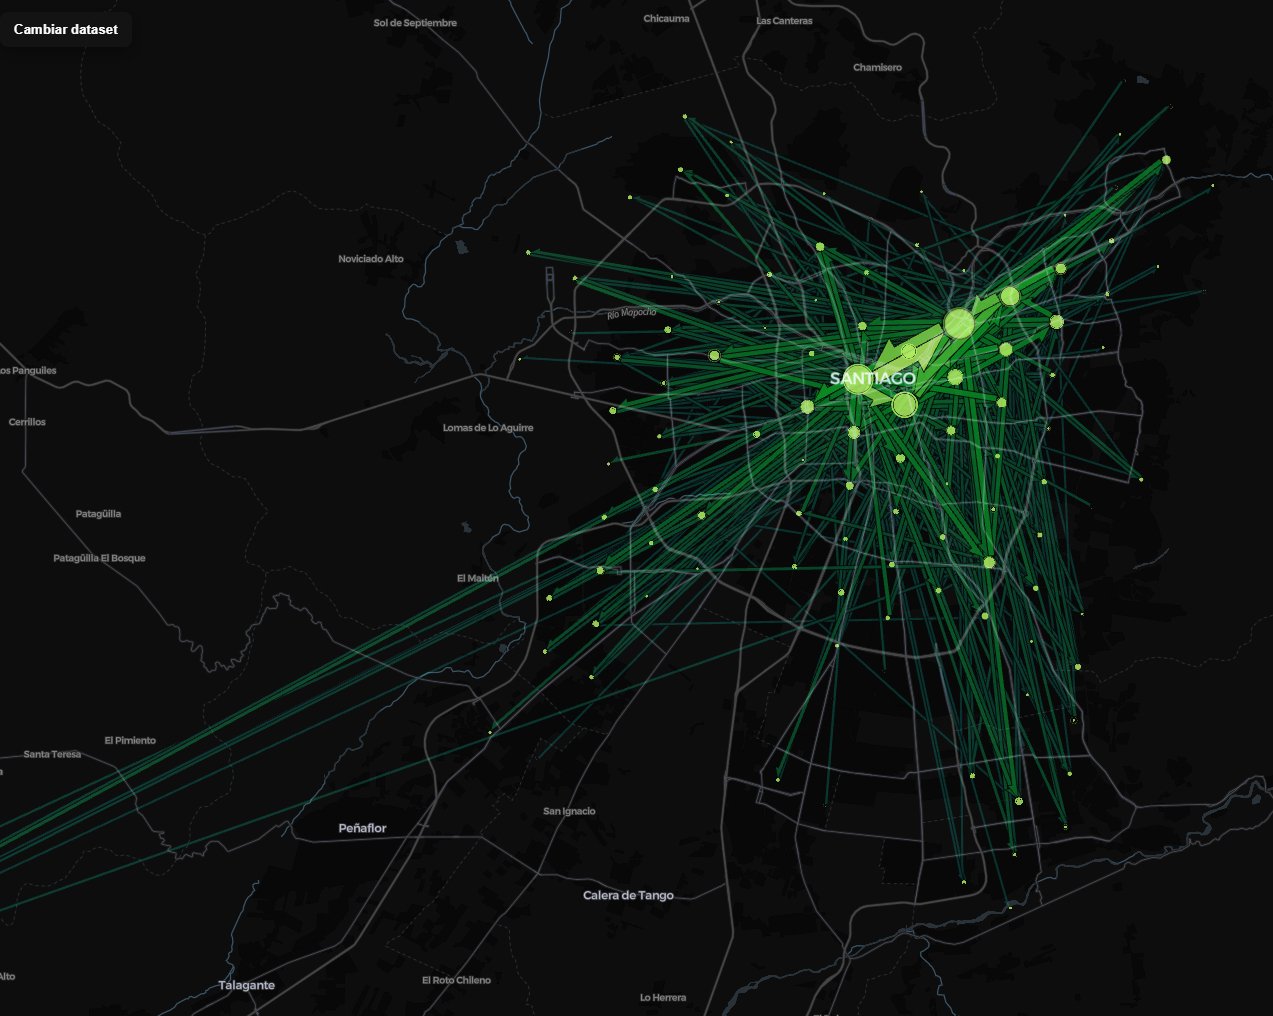

In [50]:
from IPython.display import Image
Image(REPO_ROOT / "images" / "d_rm_baseline.png")

## Captura del flowmap - RM punta AM

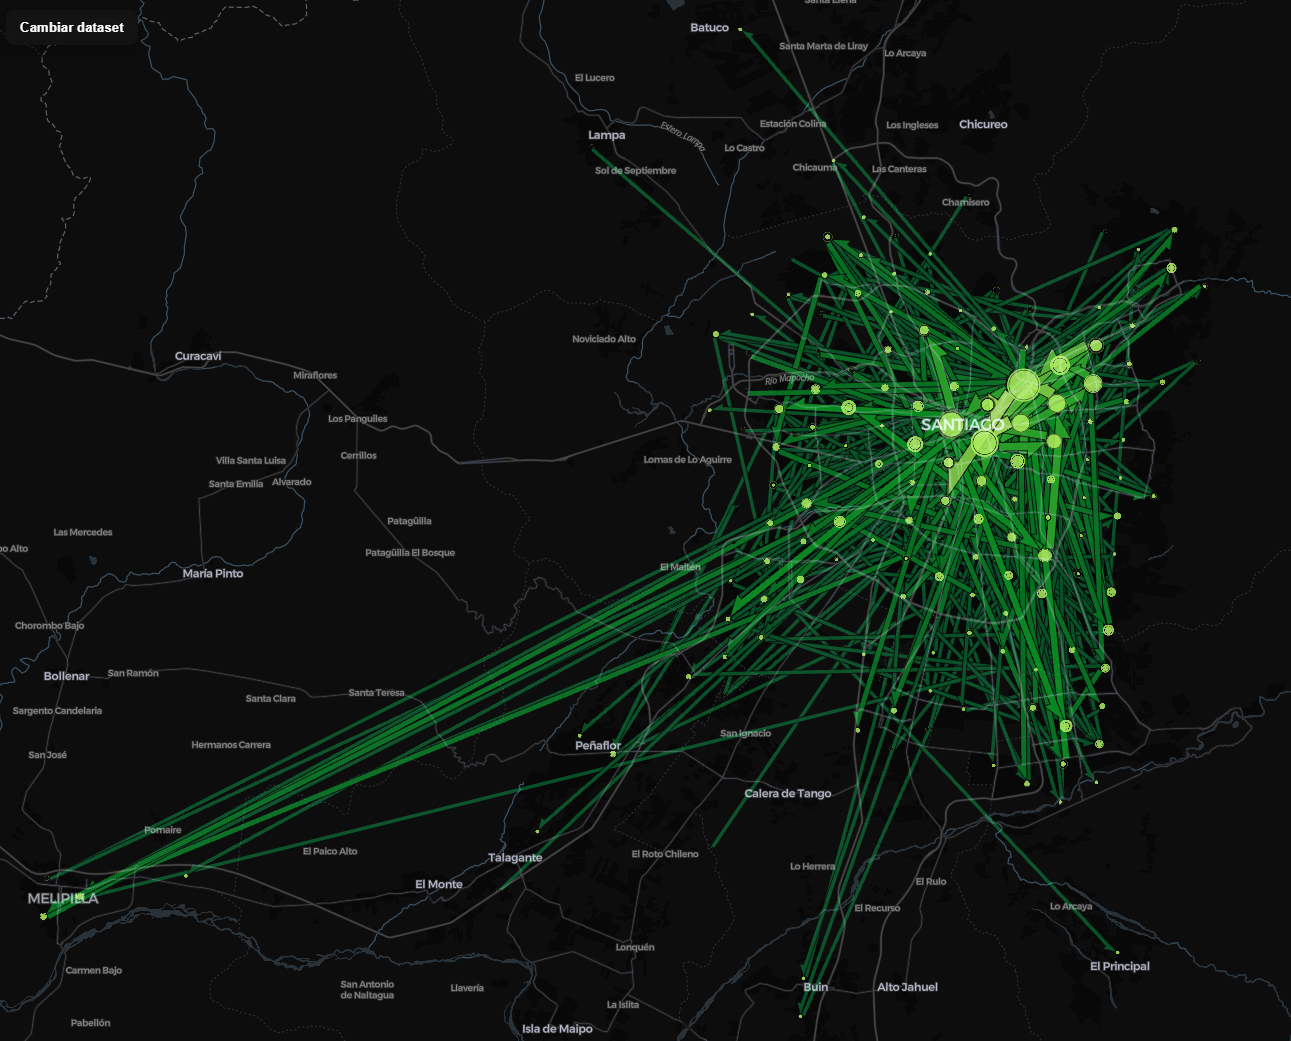

In [52]:
Image(REPO_ROOT / "images" / "d_rm_peak_am.png")

## Ruta regional mínima: Ñuble

Como contraste regional secundario, se corre una ruta mínima sobre Ñuble. Esta parte del notebook no intenta repetir toda la densidad analítica de la RM, sino comprobar que la misma cadena de traces a flows también funciona en un contexto regional distinto y de menor volumen.

In [37]:
telefonia_nuble_traces, telefonia_nuble_import_report = import_traces_from_dataframe(
    df_nuble,
    schema=TELEFONIA_TRACE_SCHEMA,
    source_name="Telefonia",
    options=TELEFONIA_TRACE_OPTIONS,
    field_correspondence=TELEFONIA_TRACE_FIELD_CORR,
    provenance=TELEFONIA_TRACE_PROVENANCE,
)

show_report_digest(telefonia_nuble_import_report, "Reporte de importación de trazas - Ñuble")


===== Reporte de importación de trazas - Ñuble =====
ok: True
summary:


,rows_in,rows_out,n_fields_mapped,point_id_generated
0,52292,52292,5,False


parameters:


,source_name,strict,keep_extra_fields,selected_fields,source_timezone,schema_version,crs,timezone,has_field_correspondence
0,Telefonia,False,True,None,None,telefonia-traces-d1,EPSG:4326,UTC,True


n_issues: 0


In [38]:
telefonia_nuble_validate_traces_report = validate_traces(
    telefonia_nuble_traces,
    options=telefonia_trace_validate_options,
)
show_report_digest(telefonia_nuble_validate_traces_report, "Validación de trazas - Ñuble")


===== Validación de trazas - Ñuble =====
ok: None
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version
0,True,52292,1,0,1,0,"{'error': 0, 'warning': 1, 'info': 0}",{'VAL.TEMPORAL.NON_MONOTONIC_TIME': 1},"[point_id, user_id, time_utc, latitude, longitude]","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'monotonic_time_per_user': True}",telefonia-traces-d1


parameters:


""
0


n_issues: 1
issue_counts_by_level:


,level,count
0,warning,1


top_issues:


,level,code,field,row_count,message
0,warning,VAL.TEMPORAL.NON_MONOTONIC_TIME,time_utc,5619,Se detectaron secuencias temporales no monotónicas por usuario en 'time_utc'.


In [39]:
telefonia_nuble_trips, telefonia_nuble_infer_report = infer_trips_from_traces(
    telefonia_nuble_traces,
    TELEFONIA_TRIPS_SCHEMA,
    options=TELEFONIA_INFER_OPTIONS,
    value_correspondence=None,
    provenance=TELEFONIA_INFER_PROVENANCE,
)
show_report_digest(telefonia_nuble_infer_report, "Inferencia de viajes - Ñuble")


===== Inferencia de viajes - Ñuble =====
ok: True
summary:


,infer_mode,n_points_in,n_candidates_in,n_candidates_dropped,n_trips_out,dropped_by_reason,n_clusters_out
0,consecutive_clusters,52292,11179,0,11179,{},52280


parameters:


,infer_mode,strict,strict_domains,require_validated_traces,drop_invalid,h3_resolution,max_time_delta_s,min_time_delta_s,min_distance_m,cluster_radius_m,cluster_max_time_gap_s,propagate_trace_fields,value_correspondence_used,validation_bypass_used
0,consecutive_clusters,False,False,True,True,10,None,None,None,250.0,300.0,{},False,False


n_issues: 3
issue_counts_by_level:


,level,count
0,info,3


top_issues:


,level,code,field,row_count,message
0,info,INF.CLUSTERS.MODE_APPLIED,None,None,Se construyeron 52280 clusters secuenciales y 11179 candidatos OD entre clusters consecutivos.
1,info,INF.H3.DERIVED,None,None,Se derivaron origin_h3_index y destination_h3_index con h3_resolution=10.
2,info,INF.OK.SUMMARY,None,None,Se infirieron 11179 viajes a partir de 52292 puntos usando infer_mode='consecutive_clusters'.


In [40]:
telefonia_nuble_validation_report_initial = validate_trips(
    telefonia_nuble_trips,
    options=telefonia_validate_trips_options,
)
show_report_digest(telefonia_nuble_validation_report_initial, "Validación inicial de trips - Ñuble")


===== Validación inicial de trips - Ñuble =====
ok: True
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version,domains,duplicates,temporal,limits
0,True,11179,0,0,0,0,"{'error': 0, 'warning': 0, 'info': 0}",{},"[destination_h3_index, destination_latitude, destination_longitude, destination_time_utc, movement_id, movement_seq, origin_h3_index, or...","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'domains': True, 'temporal_consistency': True, 'duplicates': T...",telefonia-inferred-trips-d1,"{'mode': 'sample', 'min_required_ratio': 0.95, 'fields': {}}","{'evaluated': True, 'duplicates_subset': ['movement_id'], 'n_duplicate_rows': 0}","{'evaluated': True, 'tier': 'tier_1', 'n_checked': 11179, 'n_violations': 0, 'origin_field': 'origin_time_utc', 'destination_field': 'de...","{'max_issues': 300, 'issues_truncated': False, 'n_issues_emitted': 0, 'n_issues_detected_total': 0}"


n_issues: 0


In [48]:
telefonia_flow_build_options_rm_nuble = FlowBuildOptions(
    h3_resolution=8,
    group_by=None,
    time_aggregation="none",
    keep_flow_to_trips=False,
    require_validated=True,
    min_trips_per_flow=2,
)

telefonia_nuble_flows, telefonia_nuble_build_report = build_flows(
    telefonia_nuble_trips,
    options=telefonia_flow_build_options_rm_nuble,
)
show_report_digest(telefonia_nuble_build_report, "Build flows - Ñuble")


===== Build flows - Ñuble =====
ok: True
summary:


,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,11179,11179,0,132,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,8,None,none,origin,2,False,True,False,1000


n_issues: 0


In [49]:
D_NUBLE_BASELINE_PATH = ARTIFACTS_ROOT / "d_nuble_baseline"

telefonia_nuble_write_report = write_flows(
    telefonia_nuble_flows,
    D_NUBLE_BASELINE_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

show_report_digest(telefonia_nuble_write_report, "Write flows - Ñuble baseline")

artifact_dir = D_NUBLE_BASELINE_PATH.with_suffix(".golondrina")
print(f"\nContenido del artefacto Ñuble: {artifact_dir}")
display(
    pd.DataFrame(
        [{"path": str(p), "is_file": p.is_file()} for p in sorted(artifact_dir.rglob("*")) if p != artifact_dir]
    )
)


===== Write flows - Ñuble baseline =====
ok: True
summary:


,n_flows,n_flow_to_trips,files_written,dataset_id,artifact_id,path
0,132,None,"[flows.feather, flows.metadata.json]",flows_198b3a6fd2af,art_0a58b178-d614-4b7c-b3cc-c48fe6fe7bf2,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_nuble_baseline.golondrina


parameters:


,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_nuble_baseline.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,WRITE_FLOWS.LAYOUT.BUNDLE_OVERWRITTEN,None,None,El bundle destino ya existía y será sobrescrito porque mode='overwrite'.



Contenido del artefacto Ñuble: C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_nuble_baseline.golondrina


,path,is_file
0,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_nuble_baseline.golondrina\flows.feather,True
1,C:\projects\pylondrina\data\flows\demo_6_telefonia_traces\d_nuble_baseline.golondrina\flows.metadata.json,True


## Captura del flowmap - Ñuble baseline

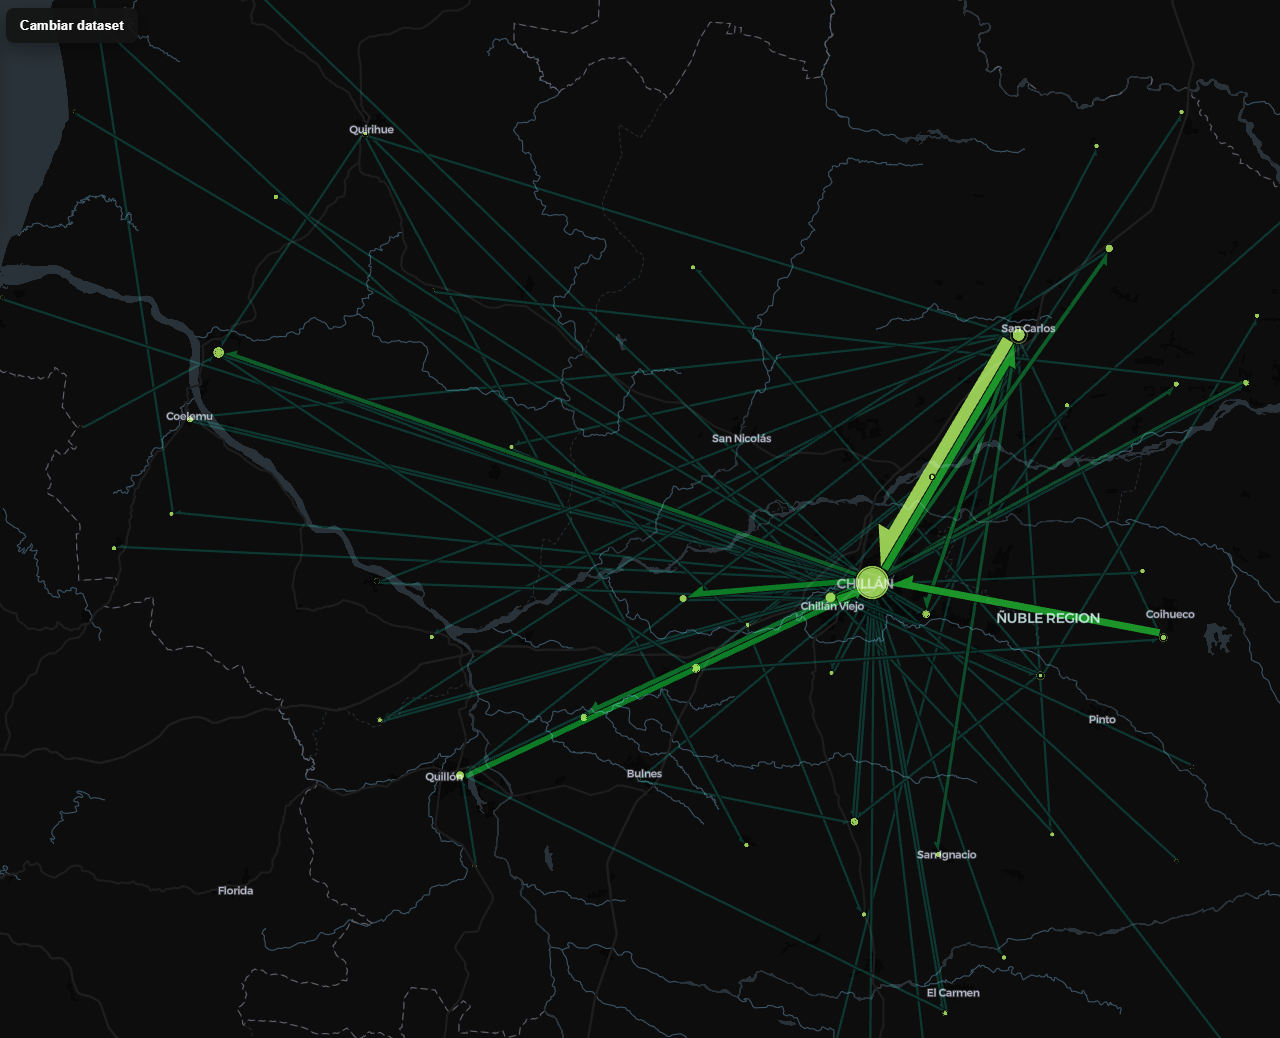

In [53]:
Image(REPO_ROOT / "images" / "d_nuble_baseline.png")

## Cierre de la prueba

Esta prueba muestra que el bloque de traces del módulo también funciona con una fuente masiva y poco semántica como telefonía. El notebook deja tres resultados principales:

1. un **baseline metropolitano** de semana completa,
2. un **contraste temporal** de punta AM en la RM,
3. y una **ruta regional mínima** en Ñuble.

En conjunto, la prueba refuerza que el valor principal de esta fuente no está en la segmentación atributiva, sino en la cobertura espacio-temporal. Aun así, el módulo logra estructurar trazas, inferir viajes simples y derivar flows persistibles y visualizables bajo el mismo contrato general usado por el resto de las fuentes.